# **12장. 시퀀스 데이터와 순환 신경망**

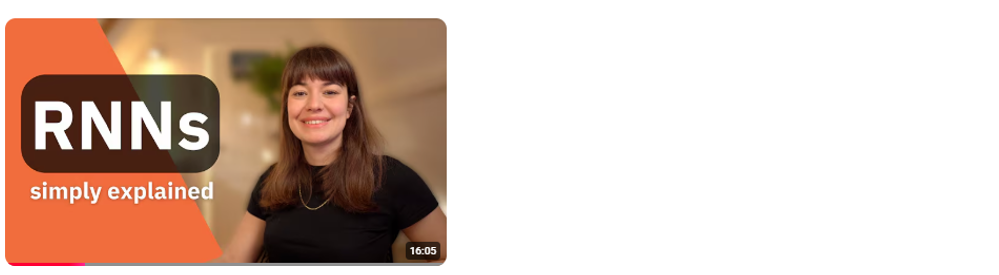

https://www.youtube.com/watch?v=y9PLF2GsD-c

이 영상은 대표적인 순환 신경망 모델인 RNN, LSTM, GRU의 구조를 잘 소개하고 있습니다.


---



[실습 12-01]

In [ ]:
# 입력 시퀀스와 타깃 만들기(다-대-일 구조)
import numpy as np; import pandas as pd

data=[1, 5, 3, 7, 10, 18, 15, 11, 17, 20]   # 10일 동안의 방문자 수

seq_length=3  # 시퀀스의 길이

X_seq, y_seq = [], []
for i in range(len(data)-seq_length):
    X_seq.append(data[i:i+seq_length])
    y_seq.append(data[i+seq_length])
X = np.array(X_seq); y = np.array(y_seq)

print(f"학습 샘플 수: {len(X)}"); print()
print("입력:"); print(X); print()
print("타깃:"); print(y); print()

학습 샘플 수: 7

입력:
[[ 1  5  3]
 [ 5  3  7]
 [ 3  7 10]
 [ 7 10 18]
 [10 18 15]
 [18 15 11]
 [15 11 17]]

타깃:
[ 7 10 18 15 11 17 20]



[실습 12-02]

In [ ]:
# 입력 시퀀스와 타깃 만들기(다-대-다 구조)

data=[1, 5, 3, 7, 10, 18, 15, 11, 17, 20]   # 10일 동안의 방문자 수

seq_length=3  # 시퀀스의 길이

X_seq, y_seq = [], []
for i in range(len(data)-seq_length):
    X_seq.append(data[i:i+seq_length])
    y_seq.append(data[i+1:i+1+seq_length])
X = np.array(X_seq); y = np.array(y_seq)

print(f"학습 샘플 수: {len(X)}"); print()
#print("입력:"); print(X); print()
print("타깃:"); print(y); print()

학습 샘플 수: 7

타깃:
[[ 5  3  7]
 [ 3  7 10]
 [ 7 10 18]
 [10 18 15]
 [18 15 11]
 [15 11 17]
 [11 17 20]]



[실습 12-03]

In [ ]:
# RNN(1)
x=[1,5,3]                   # 입력 시퀀스
h=0                         # 메모리 초기화
print("초기 기억=", h)
w=-5; v=1; b=0              # 파라미터
for t in range(len(x)):
  h=np.tanh(w*h+x[t]*v+b)   # 과거 기억과 현재 입력을 결합하여 새로운 기억 생성
  print(f"{t+1}번째 요소를 보고난 후 업데이트된 기억: {h}")

초기 기억= 0
1번째 요소를 보고난 후 업데이트된 기억: 0.7615941559557649
2번째 요소를 보고난 후 업데이트된 기억: 0.8312071485647161
3번째 요소를 보고난 후 업데이트된 기억: -0.819743743738116


라이브러리 불러오기

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential; from keras.layers import Input, Dense, SimpleRNN, LSTM, GRU
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

[실습 12-04]

             day  visitors  weekday
0     2020-01-01       455        4
1     2020-01-02       450        5
2     2020-01-03       458        6
3     2020-01-04       567        7
4     2020-01-05       550        1
...          ...       ...      ...
1090  2022-12-26       547        2
1091  2022-12-27       548        3
1092  2022-12-28       556        4
1093  2022-12-29       549        5
1094  2022-12-30       557        6

[1095 rows x 3 columns]


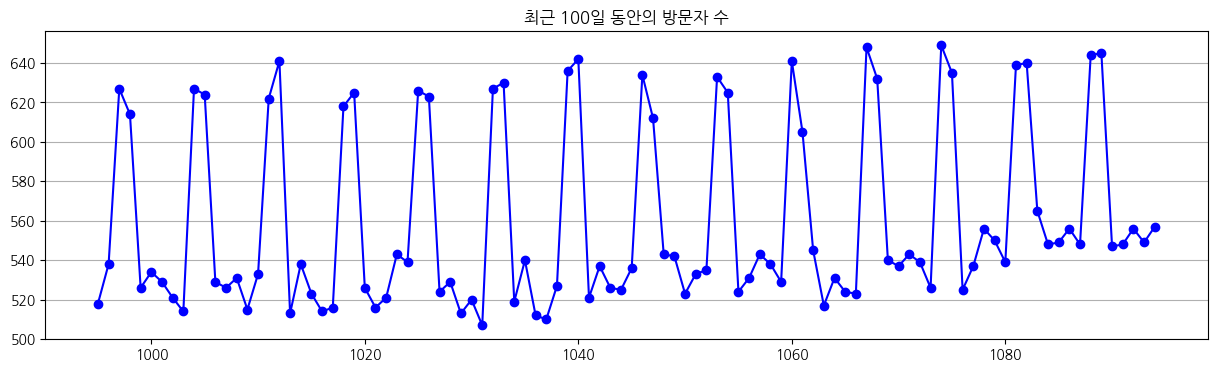

In [ ]:
df=pd.read_csv("방문자수.csv")
print(df)

# 방문자 수 시각화
plt.figure(figsize=(15, 4))
plt.plot(df['visitors'][-100:], 'bo-'); plt.title("최근 100일 동안의 방문자 수")
plt.grid(axis="y")
plt.show()

[실습 12-05]

In [ ]:
vars=df[["visitors"]]      # 분석 대상 변수 설정
num_vars=vars.shape[1]     # 변수의 개수
var_names=vars.columns

print("변수의 개수=", num_vars); print()

# 스케일 정규화
scaler_mm=MinMaxScaler()
data = scaler_mm.fit_transform(vars)
print(f"정규화된 데이터:{data.shape}")
print(data); print()


변수의 개수= 1

정규화된 데이터:(1095, 1)
[[0.17880795]
 [0.16225166]
 [0.18874172]
 ...
 [0.51324503]
 [0.49006623]
 [0.51655629]]



[실습 12-06]

In [ ]:
seq_length = 10
print("입력 시퀀스의 길이= ", seq_length); print()

X, y = [], []
for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length,:])
    y.append(data[i + seq_length,:]) # many to many
X=np.array(X); y=np.array(y)

print("전체 입력 데이터의 차원:", X.shape) # (샘플 수, 시퀀스 길이, 입력 변수의 수)
print("전체 타깃 데이터의 차원:", y.shape) # (샘플 수, 시퀀스 길이, 타깃 변수의 수)


입력 시퀀스의 길이=  10

전체 입력 데이터의 차원: (1085, 10, 1)
전체 타깃 데이터의 차원: (1085, 1)


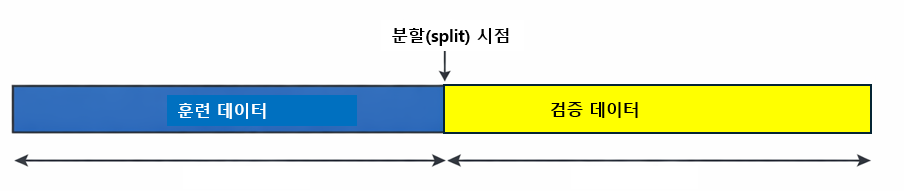

[실습 12-07]

In [ ]:
split=int(len(X)*0.8)  # 분할 시점 설정(초기 80% 시점의 정수 값)
print("분할 시점 =", split)
x_train=X[:split]; x_test=X[split:]
y_train=y[:split]; y_test=y[split:]
print("훈련용 입력 데이터 차원:", x_train.shape); print("훈련용 타깃 데이터 차원:", y_train.shape); print()
print("검증용 입력 데이터 차원:", x_test.shape); print("검증용 타깃 데이터 차원:", y_test.shape)

분할 시점 = 868
훈련용 입력 데이터 차원: (868, 10, 1)
훈련용 타깃 데이터 차원: (868, 1)

검증용 입력 데이터 차원: (217, 10, 1)
검증용 타깃 데이터 차원: (217, 1)


[실습 12-08]

In [ ]:
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

model=Sequential([
    Input(shape=(seq_length,num_vars)), # shape에 주의
    SimpleRNN(64, return_sequences=False),
    #LSTM(64),   # LSTM으로 대체
    #GRU(64),    # GRU로 대체
    Dense(16, activation='relu'),
    Dense(1) ])

model.compile(optimizer='adam', loss='mse')

early_stop=EarlyStopping(monitor="val_loss", patience=10, verbose=1, restore_best_weights=True)
history=model.fit(x_train, y_train,
                  validation_data=(x_test, y_test),
                  epochs=300,
                  callbacks=[early_stop])

Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0906 - val_loss: 0.0131
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054 - val_loss: 0.0028
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 9/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 10/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 11/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 12/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

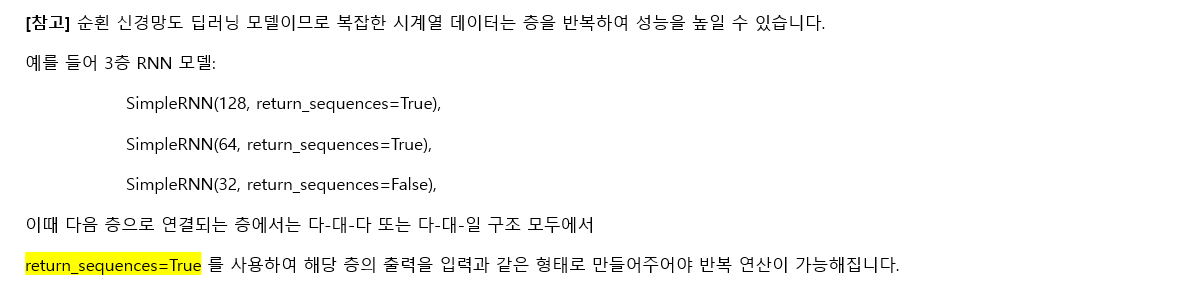

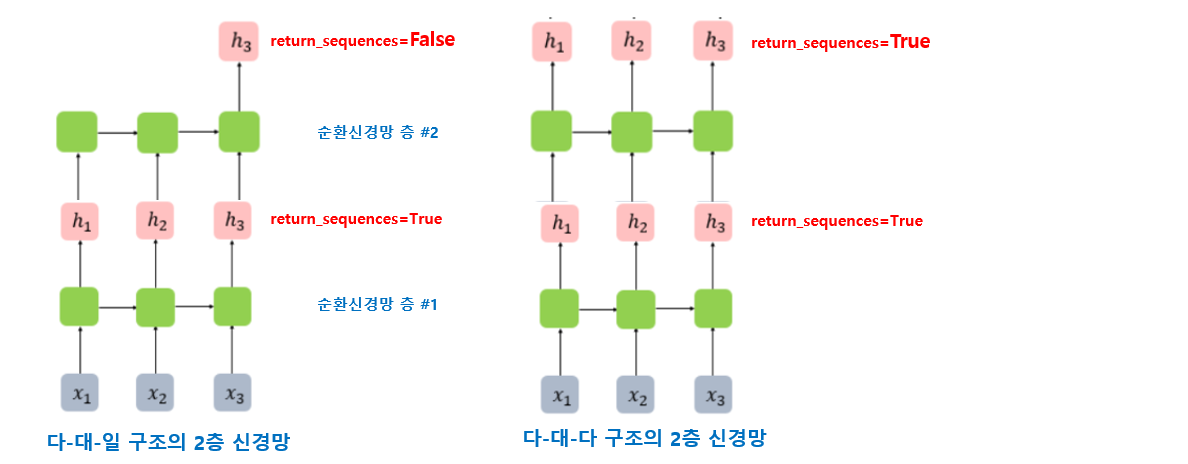

[실습 12-09]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


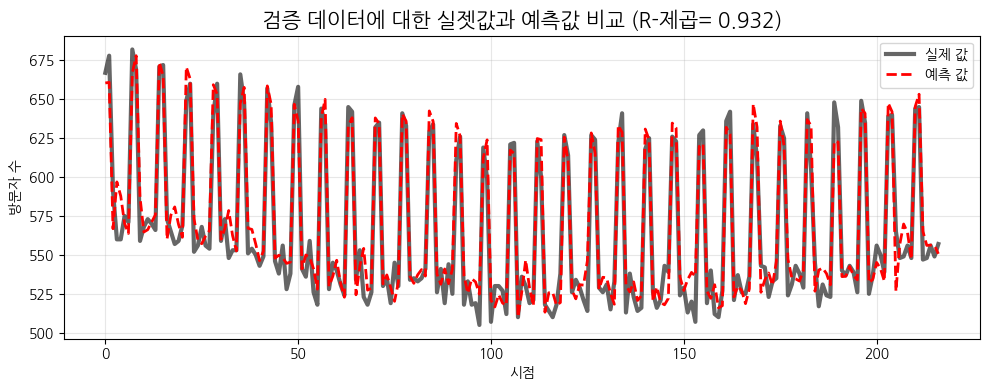

In [ ]:
# 검증 데이터에 대한 예측
y_pred = model.predict(x_test)
# 스케일 복구
y_test_inverse = scaler_mm.inverse_transform(y_test)
y_pred_inverse = scaler_mm.inverse_transform(y_pred)

R=r2_score(y_test, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_test_inverse, label='실제 값', color='black', linewidth=3, alpha=0.6)
plt.plot(y_pred_inverse, label='예측 값', color='red', linestyle='--', linewidth=2)
plt.title(f"검증 데이터에 대한 실젯값과 예측값 비교 (R-제곱={R: .3f})", fontsize=15)
plt.xlabel("시점"); plt.ylabel("방문자 수")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

[실습 12-10]

In [ ]:
def predict_future(seed_data, k_days):
    future_pred=[]
    data= seed_data.copy()
    for i in range(k_days):
        input_reshaped=data.reshape(1, seq_length, num_vars)  # 1. 모델 입력 모양 맞추기 (1, 60, 3)
        pred=model.predict(input_reshaped, verbose=0)         # 2. 다음 날 예측
        future_pred.append(pred[0])                           # 3. 예측결과 저장
        data=np.vstack([data[1:], pred])                      # 4. 시드 업데이트: 가장 오래된 데이터를 버리고 예측값을 맨 뒤에 추가
    future_pred=np.array(future_pred)                         # 5. 예측 값을 원래 스케일로 복구
    rescaled_pred=scaler_mm.inverse_transform(future_pred)
    return rescaled_pred

[실습 12-11]

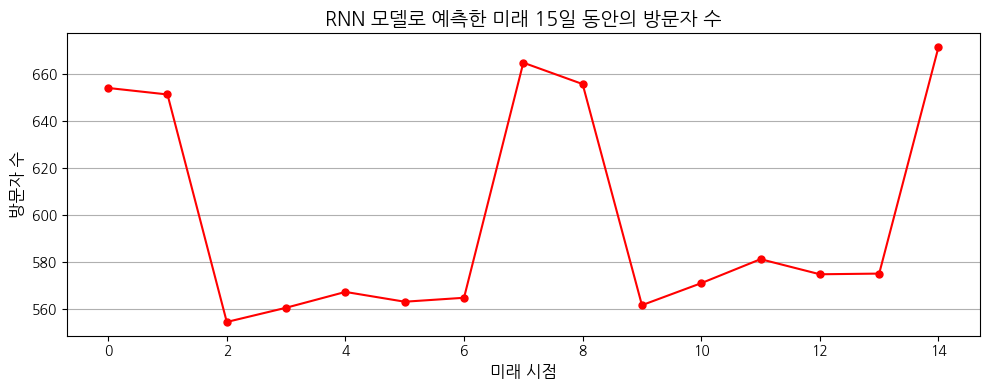

In [ ]:
K=15                               # 미래 예측 기간 설정
seed = data[-seq_length:]          # 초기 입력 데이터 설정
forecast = predict_future(seed, K) # 함수 호출
plt.figure(figsize=(10, 4))
plt.plot(forecast, color='red', marker='o', markersize=5)
plt.title(f"RNN 모델로 예측한 미래 {K}일 동안의 방문자 수", fontsize=14)
plt.xlabel("미래 시점", fontsize=12)
plt.ylabel("방문자 수", fontsize=12)
plt.grid(axis='y'); plt.tight_layout(); plt.show()



---



## **미래를 예측하는 것이 가능할까요?**
마트 방문자 수와 같은 단순한 패턴은 일부 예측 가능합니다(장기 예측은 여전히 어렵지만).

하지만 주가 예측이나 지진 예측을 떠올려 봅시다.

수학적 모델로 학습한 AI가 많이 사용되고 있지만, 여전히 정확한 예측이 되지 않습니다.

복잡한 사건은 세상의 모든 것에 **상호 의존**하므로, 예측에 필요한 모든 입력 데이터를 사용하기 어렵습니다. 따라서 예측 성능은 여전히 좋지 않습니다.

즉 현재의 AI 수준에서는 지진의 발생 지역과 시간 및 강도를 accuracy 100%로 정확하게 맞추는 것은 거의 **불가능**에 가깝습니다.

이러한 한계에서 AI는 정밀한 예측 대신에 어떤 사건(예를 들어 강도 7 이상의 지진)의 발생 가능성을 확률적으로 예측해서, 그 위험을 사전에 알려주는 현실적인 방법을 택하고 있습니다.

또한 최근에는 모델의 기본 기능인 정밀한 **예측**보다, 텍스트와 이미지 **생성** 또는 현상의 발생 과정을 **추론**하고 설명하는 기능에 중점을 두고 있습니다.
* 이건 사실 정답이 정해져 있는 문제가 아닌 **창작**의 영역입니다.
* 13장에서 생성 모델을 다룹니다.


---
## **시퀀스 모델이 왜 필요할까요?**

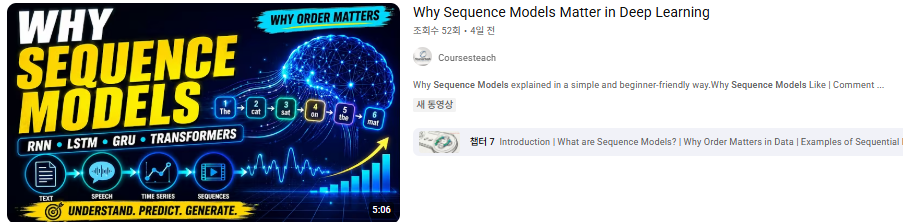

### https://www.youtube.com/watch?v=fFajncgglc0


이 동영상은 다양한 형태의 **시퀀스 데이터와 모델 구조**를 설명하고 있습니다.
* 가볍게 한번 시청하고 진행하면 도움이 됩니다.  